드라이브 연결

In [1]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Bridge Model Pipeline — Sequence cVAE ↔ SMILES cVAE

이 노트북은 PPT의 Bridge 구조에 맞춰, **이미 학습된 Sequence cVAE encoder**와 **이미 학습된 SMILES cVAE encoder**를 frozen한 뒤 `z_seq ↔ z_smi` 매핑을 학습합니다.

핵심 구조:

```text
Sequence cVAE encoder  → z_seq  (32 dim)
SMILES cVAE encoder    → z_smi  (128 dim)

Bridge_S2M: z_seq → z_smi
Bridge_M2S: z_smi → z_seq

Loss = direct alignment + cycle consistency + cosine alignment
```

중요한 주의:

- Sequence condition 순서: `[GLP1R, GIPR, GCGR]`
- SMILES condition 순서: 보통 metadata 기준 `['GLP1', 'GCGR', 'GIP']`
- 따라서 SMILES encoder에 넣기 전에 condition 순서를 자동 변환합니다.
- Bridge는 새 약물 생성기가 아니라, 두 latent space의 **alignment / 대응 관계 분석 모델**로 해석합니다.

## 0. Setup

Colab에서 실행할 경우 먼저 다음 파일들을 `/content` 또는 Drive 경로에 준비하세요.

필수 입력:

```text
Sequences.csv
SMILES.csv
milestone.csv
optimized_sequence_cvae.pt      # Sequence notebook에서 저장한 checkpoint
metadata.json                   # SMILES notebook에서 저장한 metadata
cvae_last.pt                    # SMILES notebook에서 저장한 checkpoint
```

`metadata.json`, `cvae_last.pt`는 보통 SMILES notebook의 `OUT_DIR` 안에 있습니다.

In [2]:
# 필요하면 주석 해제
!pip install -q rdkit selfies scikit-learn matplotlib joblib

import os
import json
import random
import pickle
import warnings
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)

DEVICE: cuda


path 설정

In [ ]:
from pathlib import Path
import os

# ===== Colab 환경 자동 설정 =====
# Colab이면 Google Drive를 마운트하고, 아니면 로컬 경로를 사용합니다.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.ismount('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

# === BASE_DIR: dataset/ 와 bridge/ 가 들어있는 MLProject 폴더 위치 ===
# 본인 Drive 구조에 맞게 아래 후보 경로만 수정하면 됩니다.
# 가장 먼저 존재하는 경로가 자동 선택됩니다.
_BASE_CANDIDATES = [
    Path('/content/drive/MyDrive/MLProject'),  # Drive 루트에 MLProject가 있는 경우
    Path('/content/MLProject'),                # Colab 세션에 직접 업로드한 경우
    Path('./MLProject'),                       # 로컬 실행
]
BASE_DIR = next((p for p in _BASE_CANDIDATES if p.exists()), _BASE_CANDIDATES[0])
print('BASE_DIR =>', BASE_DIR, '| exists:', BASE_DIR.exists())

DATA_DIR = f"{BASE_DIR}/dataset"
OUT_DIR = f"{BASE_DIR}/bridge"

os.makedirs(OUT_DIR, exist_ok=True)

SEQUENCES_PATH = f"{DATA_DIR}/Sequences.csv"
SMILES_PATH = f"{DATA_DIR}/SMILES.csv"
MILESTONE_PATH = f"{DATA_DIR}/milestone.csv"

# Sequence Model
SEQ_CKPT_PATH = f"{BASE_DIR}/sequence/sequence_cvae_checkpoint.pt"

# SMILES Model
SMILES_META_PATH = f"{BASE_DIR}/smiles/metadata.json"
SMILES_CKPT_PATH = f"{BASE_DIR}/smiles/cvae_gru_ep0500.pt"

for p in [
    SEQUENCES_PATH,
    SMILES_PATH,
    MILESTONE_PATH,
    SEQ_CKPT_PATH,
    SMILES_META_PATH,
    SMILES_CKPT_PATH,
]:
    print(p, "=>", os.path.exists(p))


## 2. Bridge pair 생성

Bridge에는 같은 sample에 대해 `sequence`와 `smiles`가 모두 필요합니다.

- `weak_generated`: `Sequences.csv`의 sequence를 RDKit으로 표준 peptide SMILES로 변환한 pair
- `real_milestone`: `milestone.csv`의 실제 약물 sequence-SMILES pair

weak pair는 실제 lipidation/fatty acid tail/linker/Aib 등을 반영하지 못할 수 있으므로 **pretraining용**으로 해석합니다.
real milestone pair는 **최종 평가/case study용**입니다.

In [4]:
try:
    from rdkit import Chem
except ImportError:
    import sys, subprocess
    # Python 3.12에서는 rdkit-pypi가 실패할 수 있어서 rdkit 패키지를 사용
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'rdkit'])
    from rdkit import Chem


In [5]:
seq_df = pd.read_csv(SEQUENCES_PATH)
smi_df = pd.read_csv(SMILES_PATH)
ms_df = pd.read_csv(MILESTONE_PATH)

print('Sequences:', seq_df.shape)
print('SMILES:', smi_df.shape)
print('Milestone:', ms_df.shape)

Sequences: (456, 20)
SMILES: (3540, 12)
Milestone: (12, 18)


In [6]:
import pandas as pd
import numpy as np

try:
    from rdkit import Chem
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rdkit"])
    from rdkit import Chem

STANDARD_AA = set("ACDEFGHIKLMNPQRSTVWY")

def clean_sequence(seq):
    if pd.isna(seq):
        return ""
    return str(seq).strip().upper().replace(" ", "").replace("-", "")

def sequence_to_standard_peptide_smiles(seq):
    seq = clean_sequence(seq)
    if not seq or not set(seq).issubset(STANDARD_AA):
        return None
    try:
        mol = Chem.MolFromFASTA(seq)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None

def normalize_condition_cols(frame):
    frame = frame.copy()
    for col in ["GLP1R", "GIPR", "GCGR"]:
        if col not in frame.columns:
            frame[col] = 0
        frame[col] = pd.to_numeric(frame[col], errors="coerce").fillna(0).astype(int)

    frame["condition"] = (
        frame["GLP1R"].astype(str)
        + frame["GIPR"].astype(str)
        + frame["GCGR"].astype(str)
    )
    return frame

def target_to_condition(target):
    t = str(target).upper().replace("-", "").replace("_", "").replace(" ", "")
    return pd.Series({
        "GLP1R": int(("GLP1R" in t) or ("GLP1" in t)),
        "GIPR": int(("GIPR" in t) or ("GIP" in t)),
        "GCGR": int(("GCGR" in t) or ("GLUCAGON" in t)),
    })

print("helper functions ready")

helper functions ready


In [7]:
# ===== Weak generated pairs =====
seq_pairs = seq_df.dropna(subset=['sequence']).copy()
seq_pairs['sequence'] = seq_pairs['sequence'].apply(clean_sequence)
seq_pairs = normalize_condition_cols(seq_pairs)
seq_pairs['smiles'] = seq_pairs['sequence'].apply(sequence_to_standard_peptide_smiles)

weak_pairs = seq_pairs.dropna(subset=['smiles']).copy()
weak_pairs['name'] = weak_pairs.get('label', pd.Series(['seq'] * len(weak_pairs))).astype(str) + '_' + weak_pairs.index.astype(str)
weak_pairs['pair_type'] = 'weak_generated'
weak_pairs['sample_weight'] = 1.0

weak_pairs = weak_pairs[['name', 'sequence', 'smiles', 'GLP1R', 'GIPR', 'GCGR', 'condition', 'pair_type', 'sample_weight']].reset_index(drop=True)

print('weak_pairs:', weak_pairs.shape)
print(weak_pairs['condition'].value_counts())
display(weak_pairs.head())

weak_pairs: (445, 9)
condition
100    157
101    131
010     82
001     72
110      2
111      1
Name: count, dtype: int64


,name,sequence,smiles,GLP1R,GIPR,GCGR,condition,pair_type,sample_weight
0,Glucagon_ortholog_0,HSQGTFTSDYSKYLDSRRAQQFLKWLLNV,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,0,0,1,001,weak_generated,1.0
1,Glucagon_ortholog_1,HSQGTFTSDYSKFLDTRRAQDFLDWLKNT,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,0,0,1,001,weak_generated,1.0
2,Glucagon_ortholog_2,HSQGTFTSDYSKYLDSRRAQDFVHWLMNT,CSCC[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1c[...,0,0,1,001,weak_generated,1.0
3,Glucagon_ortholog_3,HSQGTFTSDYSKYLDSRRAQDFVQWLMNN,CSCC[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1c[...,0,0,1,001,weak_generated,1.0
4,Glucagon_ortholog_4,HSQGTFTSDYSKYLDSRRAQDFVQWLMST,CSCC[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1c[...,0,0,1,001,weak_generated,1.0


In [8]:
# ===== Real milestone pairs =====
real_pairs = ms_df.copy()
if 'SMILES' in real_pairs.columns and 'smiles' not in real_pairs.columns:
    real_pairs = real_pairs.rename(columns={'SMILES': 'smiles'})

real_pairs = real_pairs.dropna(subset=['sequence', 'smiles']).copy()
real_pairs['sequence'] = real_pairs['sequence'].apply(clean_sequence)

if not all(c in real_pairs.columns for c in ['GLP1R', 'GIPR', 'GCGR']):
    target_col = 'target' if 'target' in real_pairs.columns else 'target_milestone'
    if target_col in real_pairs.columns:
        cond_df = real_pairs[target_col].apply(target_to_condition)
        real_pairs = pd.concat([real_pairs.reset_index(drop=True), cond_df.reset_index(drop=True)], axis=1)
    else:
        raise ValueError('milestone.csv에 GLP1R/GIPR/GCGR 또는 target column이 필요합니다.')
else:
    real_pairs = normalize_condition_cols(real_pairs)

real_pairs = normalize_condition_cols(real_pairs)
real_pairs['pair_type'] = 'real_milestone'
real_pairs['sample_weight'] = 5.0

# name column 보장
if 'name' not in real_pairs.columns:
    real_pairs['name'] = [f'milestone_{i}' for i in range(len(real_pairs))]

real_pairs = real_pairs[['name', 'sequence', 'smiles', 'GLP1R', 'GIPR', 'GCGR', 'condition', 'pair_type', 'sample_weight']].reset_index(drop=True)

print('real_pairs:', real_pairs.shape)
print(real_pairs[['name', 'condition']])

real_pairs: (12, 9)
              name condition
0      GLP-1(7-36)       100
1        GIP(1-42)       010
2   Glucagon(1-29)       001
3        Exenatide       100
4     Lixisenatide       100
5      Liraglutide       100
6      Albiglutide       100
7     Taspoglutide       100
8      Dulaglutide       100
9      Semaglutide       100
10     Tirzepatide       110
11     Retatrutide       111


In [9]:
bridge_pairs = pd.concat([weak_pairs, real_pairs], ignore_index=True)
bridge_pairs.insert(0, 'pair_id', [f'pair_{i:04d}' for i in range(len(bridge_pairs))])

WEAK_PAIR_PATH = os.path.join(OUT_DIR, 'bridge_pairs_weak_generated.csv')
REAL_PAIR_PATH = os.path.join(OUT_DIR, 'bridge_pairs_real_milestone.csv')
COMBINED_PAIR_PATH = os.path.join(OUT_DIR, 'bridge_pairs_combined.csv')

weak_pairs.to_csv(WEAK_PAIR_PATH, index=False)
real_pairs.to_csv(REAL_PAIR_PATH, index=False)
bridge_pairs.to_csv(COMBINED_PAIR_PATH, index=False)

print('Saved:')
print(WEAK_PAIR_PATH)
print(REAL_PAIR_PATH)
print(COMBINED_PAIR_PATH)
print()
print(bridge_pairs['pair_type'].value_counts())
print(bridge_pairs['condition'].value_counts())

Saved:
MLProject/bridge/bridge_pairs_weak_generated.csv
MLProject/bridge/bridge_pairs_real_milestone.csv
MLProject/bridge/bridge_pairs_combined.csv

pair_type
weak_generated    445
real_milestone     12
Name: count, dtype: int64
condition
100    165
101    131
010     83
001     73
110      3
111      2
Name: count, dtype: int64


## 3. Sequence cVAE 로드

`Sequence_VAE_cleaned.ipynb`에서 저장한 `optimized_sequence_cvae.pt`를 로드합니다.

저장 파일에는 `model_state_dict`, `vocab`, `stoi`, `itos`, `max_len`, `config`가 들어 있어야 합니다.

In [10]:
class ConditionalSequenceVAEAux(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len,
        pad_idx,
        condition_dim=3,
        embed_dim=64,
        hidden_dim=128,
        latent_dim=32,
        cond_hidden_dim=32,
        dropout=0.2,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.pad_idx = pad_idx
        self.latent_dim = latent_dim
        self.condition_dim = condition_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        self.cond_encoder = nn.Sequential(
            nn.Linear(condition_dim, cond_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(embed_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.fc_mu = nn.Linear(hidden_dim + cond_hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + cond_hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, max_len * vocab_size),
        )

        self.condition_classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, condition_dim),
        )

    def encode(self, x, c):
        batch_size, seq_len = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        token_emb = self.embedding(x)
        pos_emb = self.pos_embedding(positions)
        h = token_emb + pos_emb
        h = h.transpose(1, 2)
        h = self.encoder_cnn(h)
        h = h.mean(dim=2)
        c_emb = self.cond_encoder(c)
        h_cond = torch.cat([h, c_emb], dim=1)
        mu = self.fc_mu(h_cond)
        logvar = self.fc_logvar(h_cond)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + torch.randn_like(std) * std
        return mu

    def decode(self, z, c):
        c_emb = self.cond_encoder(c)
        z_cond = torch.cat([z, c_emb], dim=1)
        logits = self.decoder(z_cond)
        return logits.view(-1, self.max_len, self.vocab_size)

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, c)
        condition_logits = self.condition_classifier(mu)
        return logits, mu, logvar, condition_logits

In [11]:
seq_ckpt = torch.load(SEQ_CKPT_PATH, map_location=DEVICE)

seq_vocab = seq_ckpt['vocab']
seq_stoi = seq_ckpt['stoi']
seq_itos = seq_ckpt['itos']
seq_max_len = seq_ckpt['max_len']
seq_config = seq_ckpt.get('config', {})

SEQ_PAD = '<PAD>'
SEQ_SOS = '<SOS>'
SEQ_EOS = '<EOS>'
seq_pad_idx = seq_stoi[SEQ_PAD]

sequence_model = ConditionalSequenceVAEAux(
    vocab_size=len(seq_vocab),
    max_len=seq_max_len,
    pad_idx=seq_pad_idx,
    condition_dim=3,
    embed_dim=seq_config.get('embed_dim', 64),
    hidden_dim=seq_config.get('hidden_dim', 128),
    latent_dim=seq_config.get('latent_dim', 32),
    cond_hidden_dim=seq_config.get('cond_hidden_dim', 32),
    dropout=seq_config.get('dropout', 0.2),
).to(DEVICE)

sequence_model.load_state_dict(seq_ckpt['model_state_dict'])
sequence_model.eval()

SEQ_LATENT_DIM = seq_config.get('latent_dim', 32)
print('Sequence cVAE loaded')
print('seq vocab:', len(seq_vocab), 'seq max_len:', seq_max_len, 'z_seq_dim:', SEQ_LATENT_DIM)

Sequence cVAE loaded
seq vocab: 24 seq max_len: 46 z_seq_dim: 32


In [12]:
def encode_sequence_for_bridge(seq, stoi, max_len):
    seq = clean_sequence(seq)
    tokens = [stoi[SEQ_SOS]]
    for ch in seq:
        if ch in stoi:
            tokens.append(stoi[ch])
        else:
            # sequence model vocab에 없는 비표준 문자는 X가 있으면 X로 대체, 없으면 skip
            if 'X' in stoi:
                tokens.append(stoi['X'])
    tokens.append(stoi[SEQ_EOS])
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
    tokens += [stoi[SEQ_PAD]] * (max_len - len(tokens))
    return torch.tensor(tokens, dtype=torch.long)

@torch.no_grad()
def get_z_seq(seq, condition_seq_order):
    """condition_seq_order = [GLP1R, GIPR, GCGR]"""
    x = encode_sequence_for_bridge(seq, seq_stoi, seq_max_len).unsqueeze(0).to(DEVICE)
    c = torch.tensor([condition_seq_order], dtype=torch.float32).to(DEVICE)
    mu, logvar = sequence_model.encode(x, c)
    return mu.squeeze(0).cpu().numpy()

## 4. SMILES cVAE 로드 (최종 FPGRUcVAE 구조에 맞춤)

최종 SMILES VAE는 **fingerprint + SELFIES-BPE 토큰 + 조건 벡터**를 입력으로 받는 `FPGRUcVAE`입니다.
Bridge에는 latent만 필요하므로 그 안의 **encoder만** 복원해서 로드합니다.

이 노트북이 기대하는 형태:

- 입력: Morgan fingerprint(`N_BITS_MG`) + SELFIES-BPE 토큰(`MAX_LEN`) + 조건 벡터(`COND_LABELS` 순서, multi-hot)
- 체크포인트: `{"epoch", "state_dict", "metadata"}` 래퍼 (metadata 내장). 과거의 순수 state_dict도 처리.
- metadata: 체크포인트 내장본 우선, 없으면 `metadata.json` 사용. tokenizer(BPE)·fingerprint·condition·model 차원을 여기서 읽습니다.
- 조건은 class_id로 collapse하지 않고 **3차원 벡터 그대로** 넣으므로, dual/triple 타깃(110·111)도 올바르게 인코딩됩니다.

In [13]:
try:
    import selfies as sf
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'selfies'])
    import selfies as sf
from rdkit.Chem import AllChem

# === 체크포인트 로드 (최종 SMILES VAE는 {"state_dict","metadata"} 래퍼로 저장됨) ===
_ckpt = torch.load(SMILES_CKPT_PATH, map_location=DEVICE)
if isinstance(_ckpt, dict) and 'state_dict' in _ckpt:
    smi_state = _ckpt['state_dict']
    _meta_ck  = _ckpt.get('metadata', None)
else:                                   # 과거: 순수 state_dict만 저장된 경우
    smi_state = _ckpt
    _meta_ck  = None

# metadata: 체크포인트 내장본 우선, 없으면 metadata.json
if _meta_ck is not None:
    smi_meta = _meta_ck
    print('metadata source: checkpoint (embedded)')
else:
    with open(SMILES_META_PATH, 'r', encoding='utf-8') as f:
        smi_meta = json.load(f)
    print('metadata source: metadata.json')

# --- tokenizer (SELFIES + BPE) ---
tok = smi_meta['tokenizer']
SMI_TOKEN_TYPE = tok.get('type', 'bpe')
VOCAB_SIZE = int(tok['vocab_size'])
MAX_LEN    = int(tok['max_len'])
PAD_IDX, SOS_IDX = int(tok['pad_idx']), int(tok['sos_idx'])
EOS_IDX, UNK_IDX = int(tok['eos_idx']), int(tok['unk_idx'])

if SMI_TOKEN_TYPE != 'bpe' or 'bpe_c2i' not in tok:
    raise RuntimeError(
        '이 노트북은 최종 SELFIES-BPE tokenizer를 기대합니다. '
        'metadata에 bpe_c2i/bpe_merges가 없으면, metadata가 내장된 cvae_gru_last.pt를 사용하세요.')

bpe_c2i = dict(tok['bpe_c2i'])                          # token str -> id
bpe_i2c = {int(k): v for k, v in tok['bpe_i2c'].items()}  # id -> token str
bpe_merges = {}                                         # (a,b) -> merged token (순서 보존)
for k, v in tok['bpe_merges'].items():
    a, b = k.split('\x00')
    bpe_merges[(a, b)] = v

# --- fingerprint ---
fp_meta   = smi_meta['fingerprint']
N_BITS_MG = int(fp_meta.get('n_bits_mg', fp_meta.get('n_bits', 1024)))
RADIUS    = int(fp_meta['radius'])

# --- condition ---
cond_meta   = smi_meta['condition']
COND_LABELS = cond_meta['cond_labels']
N_COND      = int(cond_meta['n_cond'])

# --- model dims ---
m = smi_meta['model']
EMB_DIM    = int(m['emb_dim'])
LATENT_DIM = int(m['latent_dim'])
DROPOUT    = float(m.get('dropout', 0.1))
SMI_LATENT_DIM = LATENT_DIM

print('SMILES metadata loaded (SELFIES-BPE encoder)')
print(f'  vocab={VOCAB_SIZE} max_len={MAX_LEN} n_bits={N_BITS_MG} radius={RADIUS}')
print(f'  cond_labels={COND_LABELS} n_cond={N_COND}')
print(f'  emb_dim={EMB_DIM} z_smi_dim={SMI_LATENT_DIM}')

metadata source: checkpoint (embedded)
SMILES metadata loaded (SELFIES-BPE encoder)
  vocab=250 max_len=116 n_bits=1024 radius=4
  cond_labels=['GLP1', 'GCGR', 'GIP'] n_cond=3
  emb_dim=64 z_smi_dim=128


In [14]:
def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)

def smiles_to_selfies_str(smi):
    try:
        if smi in (None, '', 'nan', 'None'):
            return None
        return sf.encoder(str(smi))
    except Exception:
        return None

def apply_bpe(sf_str_or_toks, merges, c2i):
    if isinstance(sf_str_or_toks, (list, tuple)):
        toks = tuple(sf_str_or_toks)
    else:
        toks = tuple(sf.split_selfies(sf_str_or_toks)) if sf_str_or_toks else ()
    for (a, b), merged in merges.items():
        out, i = [], 0
        while i < len(toks):
            if i < len(toks) - 1 and toks[i] == a and toks[i + 1] == b:
                out.append(merged); i += 2
            else:
                out.append(toks[i]); i += 1
        toks = tuple(out)
    return [c2i.get(t, UNK_IDX) for t in toks]

def encode_smi(smi):
    'SMILES -> SELFIES -> BPE ids -> [SOS]+ids+[EOS] (MAX_LEN 초과 시 절단)'
    sf_str = smiles_to_selfies_str(smi)
    if sf_str is None:
        sf_str = ''
    ids = apply_bpe(sf_str, bpe_merges, bpe_c2i)
    tokens = [SOS_IDX] + ids + [EOS_IDX]
    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN - 1] + [EOS_IDX]
    return tokens

def pad_tokens(ids):
    ids = list(ids)[:MAX_LEN]
    return ids + [PAD_IDX] * (MAX_LEN - len(ids))

def smiles_to_fp(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    morgan = AllChem.GetMorganFingerprintAsBitVect(mol, radius=RADIUS, nBits=N_BITS_MG)
    return np.asarray(morgan, dtype=np.float32)

def condition_for_smiles_model(GLP1R, GIPR, GCGR):
    'map Bridge [GLP1R,GIPR,GCGR] to SMILES model COND_LABELS-order vector (multi-hot)'
    out = []
    for lab in COND_LABELS:
        key = str(lab).upper().replace('_', '').replace('-', '')
        if key in ('GLP1', 'GLP1R'):
            out.append(float(GLP1R))
        elif key in ('GIP', 'GIPR'):
            out.append(float(GIPR))
        elif key in ('GCGR', 'GCG', 'GLUCAGON'):
            out.append(float(GCGR))
        else:
            raise ValueError(f'Unknown SMILES condition label: {lab}')
    return out

print('SMILES helpers ready (encode_smi / smiles_to_fp / condition_for_smiles_model)')

SMILES helpers ready (encode_smi / smiles_to_fp / condition_for_smiles_model)


In [15]:
class SMILESEncoder(nn.Module):
    'encoder identical to final FPGRUcVAE (fp + SELFIES-CNN + cond)'
    def __init__(self):
        super().__init__()
        self.fp_net = nn.Sequential(
            nn.Linear(N_BITS_MG, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(512, 256),       nn.LayerNorm(256), nn.GELU(), nn.Dropout(DROPOUT),
        )
        self.seq_emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=PAD_IDX)
        self.ch = 64
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(EMB_DIM, self.ch, kernel_size=k, padding=k // 2), nn.GELU(),
                nn.Conv1d(self.ch, self.ch, kernel_size=k, padding=k // 2), nn.GELU(),
            ) for k in [3, 4, 5]
        ])
        CNN_OUT = self.ch * 3
        self.fuse = nn.Sequential(
            nn.Linear(256 + CNN_OUT + N_COND, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(DROPOUT),
        )
        self.fc_mu     = nn.Linear(256, LATENT_DIM)
        self.fc_logvar = nn.Linear(256, LATENT_DIM)

    def forward(self, fp, cond, tokens=None):
        fp_h = self.fp_net(fp)
        if tokens is not None:
            x = self.seq_emb(tokens).permute(0, 2, 1)
            seq_h = torch.cat([conv(x).max(dim=-1).values for conv in self.convs], dim=-1)
        else:
            seq_h = torch.zeros(fp.size(0), self.ch * len(self.convs), device=fp.device)
        h = self.fuse(torch.cat([fp_h, seq_h, cond], dim=-1))
        return self.fc_mu(h), self.fc_logvar(h)

print('SMILESEncoder defined')

SMILESEncoder defined


In [16]:
smiles_model = SMILESEncoder().to(DEVICE)

# 전체 모델 state_dict에서 encoder.* 만 추출 (decoder/fp_decoder는 latent 추출에 불필요)
encoder_state = {k[len('encoder.'):]: v for k, v in smi_state.items() if k.startswith('encoder.')}
if len(encoder_state) == 0:
    # 혹시 이미 encoder만 저장된 경우
    encoder_state = {k: v for k, v in smi_state.items() if not k.startswith(('fp_decoder.', 'smi_decoder.'))}

missing, unexpected = smiles_model.load_state_dict(encoder_state, strict=False)
smiles_model.eval()
print('SMILES encoder loaded')
print('  loaded params:', len(encoder_state))
print('  missing:', missing)
print('  unexpected:', unexpected)
assert len(missing) == 0, '인코더 가중치 일부가 로드되지 않았습니다. 체크포인트/구조를 확인하세요.'

SMILES encoder loaded
  loaded params: 29
  missing: []
  unexpected: []


In [17]:
def canonicalize_for_smi_vae(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    mol = Chem.RemoveHs(mol)
    frags = Chem.GetMolFrags(mol, asMols=True)
    mol = max(frags, key=lambda m: m.GetNumAtoms())
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)

In [18]:
@torch.no_grad()
def get_z_smi(smi, condition_seq_order):
    'condition_seq_order = [GLP1R, GIPR, GCGR]; returns mu(z_smi)'
    GLP1R, GIPR, GCGR = [int(x) for x in condition_seq_order]

    smi = canonicalize_for_smi_vae(smi)
    if smi is None:
        raise ValueError(f'invalid SMILES: {str(smi)[:40]}')

    fp = smiles_to_fp(smi)
    if fp is None:
        raise ValueError(f'invalid SMILES (fp 생성 실패): {str(smi)[:40]}')

    fp_t = torch.tensor(fp, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    tok_t = torch.tensor(
        [pad_tokens(encode_smi(smi))],
        dtype=torch.long,
        device=DEVICE
    )

    cond_t = torch.tensor(
        [condition_for_smiles_model(GLP1R, GIPR, GCGR)],
        dtype=torch.float32,
        device=DEVICE
    )

    mu, logvar = smiles_model(fp_t, cond_t, tokens=tok_t)
    return mu.squeeze(0).cpu().numpy()

# 빠른 점검
try:
    _z = get_z_smi('CCO', [1, 0, 0])
    print('get_z_smi OK, z_smi dim =', _z.shape[0])
except Exception as e:
    print('get_z_smi 테스트 실패:', e)

get_z_smi OK, z_smi dim = 128


## 5. Pair별 latent 추출

이 단계에서 최종 Bridge 학습용 `bridge_latents.csv`를 만듭니다.

- `z_seq_0 ... z_seq_31`
- `z_smi_0 ... z_smi_127`

In [19]:
def extract_bridge_latents(pairs_df):
    rows = []
    z_seq_list = []
    z_smi_list = []

    for i, row in pairs_df.reset_index(drop=True).iterrows():
        condition = [int(row['GLP1R']), int(row['GIPR']), int(row['GCGR'])]
        try:
            z_seq = get_z_seq(row['sequence'], condition)
            z_smi = get_z_smi(row['smiles'], condition)
        except Exception as e:
            print(f'[skip] {i} {row.get("name", "")}: {e}')
            continue

        base = row.to_dict()
        rows.append(base)
        z_seq_list.append(z_seq)
        z_smi_list.append(z_smi)

    latent_df = pd.DataFrame(rows).reset_index(drop=True)
    Z_seq = np.vstack(z_seq_list).astype('float32')
    Z_smi = np.vstack(z_smi_list).astype('float32')

    for j in range(Z_seq.shape[1]):
        latent_df[f'z_seq_{j}'] = Z_seq[:, j]
    for j in range(Z_smi.shape[1]):
        latent_df[f'z_smi_{j}'] = Z_smi[:, j]

    return latent_df

LATENT_PATH = os.path.join(OUT_DIR, 'bridge_latents.csv')
latent_df = extract_bridge_latents(bridge_pairs)
latent_df.to_csv(LATENT_PATH, index=False)
print('Saved:', LATENT_PATH)

"""
if os.path.exists(LATENT_PATH):
    latent_df = pd.read_csv(LATENT_PATH)
    print('Loaded existing latent_df:', latent_df.shape)
else:
    latent_df = extract_bridge_latents(bridge_pairs)
    latent_df.to_csv(LATENT_PATH, index=False)
    print('Saved:', LATENT_PATH)
"""
print('latent_df:', latent_df.shape)
print(latent_df['pair_type'].value_counts())
display(latent_df.head())

Saved: MLProject/bridge/bridge_latents.csv
latent_df: (457, 170)
pair_type
weak_generated    445
real_milestone     12
Name: count, dtype: int64


,pair_id,name,sequence,smiles,GLP1R,GIPR,GCGR,condition,pair_type,sample_weight,...,z_smi_118,z_smi_119,z_smi_120,z_smi_121,z_smi_122,z_smi_123,z_smi_124,z_smi_125,z_smi_126,z_smi_127
0,pair_0000,Glucagon_ortholog_0,HSQGTFTSDYSKYLDSRRAQQFLKWLLNV,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,0,0,1,001,weak_generated,1.0,...,-0.388266,-0.355526,0.290591,-0.315763,0.309464,0.261694,-0.201320,-0.159202,-0.000442,-0.498322
1,pair_0001,Glucagon_ortholog_1,HSQGTFTSDYSKFLDTRRAQDFLDWLKNT,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](...,0,0,1,001,weak_generated,1.0,...,-0.350828,-0.317256,0.264357,-0.318949,0.334649,0.263681,-0.263154,-0.143077,-0.010167,-0.462612
2,pair_0002,Glucagon_ortholog_2,HSQGTFTSDYSKYLDSRRAQDFVHWLMNT,CSCC[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1c[...,0,0,1,001,weak_generated,1.0,...,-0.360852,-0.358833,0.285980,-0.335471,0.314860,0.243326,-0.200525,-0.120195,-0.033786,-0.489853
3,pair_0003,Glucagon_ortholog_3,HSQGTFTSDYSKYLDSRRAQDFVQWLMNN,CSCC[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1c[...,0,0,1,001,weak_generated,1.0,...,-0.379219,-0.392482,0.305133,-0.349458,0.308435,0.260873,-0.181178,-0.132161,-0.026369,-0.507484
4,pair_0004,Glucagon_ortholog_4,HSQGTFTSDYSKYLDSRRAQDFVQWLMST,CSCC[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1c[...,0,0,1,001,weak_generated,1.0,...,-0.367123,-0.344476,0.275664,-0.315525,0.304713,0.249500,-0.188021,-0.132427,-0.023843,-0.471219


## 6. Bridge 학습 준비

z_seq와 z_smi는 차원과 scale이 다르므로, Bridge 학습에서는 train set 기준으로 각각 standardization합니다.

- train: `weak_generated`
- eval/test: `real_milestone`

real milestone을 학습에 넣으면 12개를 외울 위험이 크기 때문에, 기본 설정은 **weak pair로 학습하고 real milestone으로 평가**합니다.

## 6.0 Latent 진단 (bridge 전에 먼저)

업데이트된 두 인코더의 latent 공간이 **posterior collapse 없이 충분한 자유도**를 갖는지 확인합니다.
죽은 차원이 많으면 "정렬이 잘 된다"가 사실은 "둘 다 평균으로 collapse"일 수 있으므로,
bridge 수치를 해석하기 전에 반드시 봐야 합니다.

=== per-dim variance (raw latent) ===
[z_seq] dim= 32  active(var>0.001)= 32  mean|mu|=1.163  var=[0.1085, 3.8652]
[z_smi] dim=128  active(var>0.001)=128  mean|mu|=0.205  var=[0.0021, 0.0643]


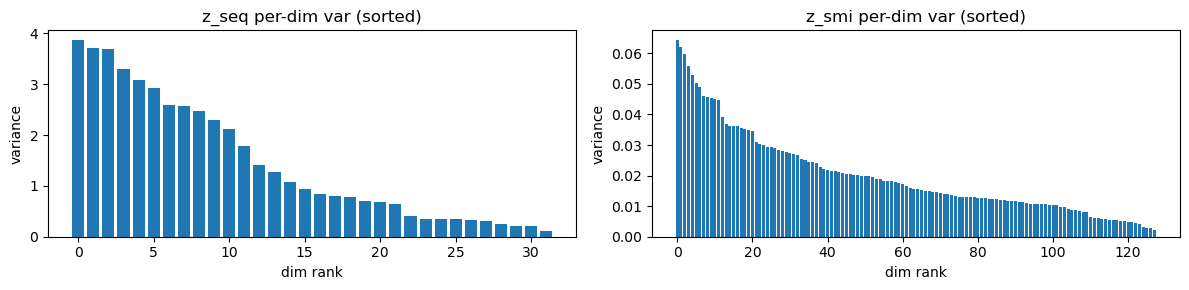

mean |offdiag corr|  z_seq=0.490  z_smi=0.538
-> active dim이 너무 적거나 offdiag corr가 높으면 상류 VAE의 KL/free-bits를 점검하세요.


In [20]:
import re

z_seq_cols = [c for c in latent_df.columns if re.fullmatch(r'z_seq_\d+', c)]
z_smi_cols = [c for c in latent_df.columns if re.fullmatch(r'z_smi_\d+', c)]
Z_seq_raw = latent_df[z_seq_cols].values.astype('float32')
Z_smi_raw = latent_df[z_smi_cols].values.astype('float32')

def latent_report(Z, name, var_thresh=1e-3):
    var = Z.var(axis=0)
    active = int((var > var_thresh).sum())
    print(f'[{name}] dim={Z.shape[1]:>3}  active(var>{var_thresh})={active:>3}  '
          f'mean|mu|={np.abs(Z).mean():.3f}  var=[{var.min():.4f}, {var.max():.4f}]')
    return var

print('=== per-dim variance (raw latent) ===')
var_seq = latent_report(Z_seq_raw, 'z_seq')
var_smi = latent_report(Z_smi_raw, 'z_smi')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].bar(range(len(var_seq)), np.sort(var_seq)[::-1]); axes[0].set_title('z_seq per-dim var (sorted)')
axes[1].bar(range(len(var_smi)), np.sort(var_smi)[::-1]); axes[1].set_title('z_smi per-dim var (sorted)')
for ax in axes: ax.set_xlabel('dim rank'); ax.set_ylabel('variance')
plt.tight_layout(); plt.show()

# 차원 간 상관 (중복/redundant 차원 탐지): 평균 절대 오프대각 상관이 높으면 차원이 사실상 중복
def offdiag_corr(Z):
    C = np.corrcoef(Z.T)
    m = ~np.eye(C.shape[0], dtype=bool)
    return np.nanmean(np.abs(C[m]))
print(f'mean |offdiag corr|  z_seq={offdiag_corr(Z_seq_raw):.3f}  z_smi={offdiag_corr(Z_smi_raw):.3f}')
print('-> active dim이 너무 적거나 offdiag corr가 높으면 상류 VAE의 KL/free-bits를 점검하세요.')

In [21]:
def eff_dim(Z):
    cov = np.cov(Z - Z.mean(0), rowvar=False)
    ev = np.linalg.eigvalsh(cov); ev = ev[ev > 0]
    return (ev.sum()**2) / (ev**2).sum()
print('effective dim  z_seq=%.1f / 32   z_smi=%.1f / 128' % (eff_dim(Z_seq_raw), eff_dim(Z_smi_raw)))

effective dim  z_seq=2.2 / 32   z_smi=2.0 / 128


In [22]:
def cond_var_explained(Z, cond_str):
    Z = Z - Z.mean(0); total = (Z**2).sum(); resid = 0.0
    for c in np.unique(cond_str):
        m = cond_str.values == c
        resid += ((Z[m] - Z[m].mean(0))**2).sum()
    return 1 - resid/total

cs = latent_df['condition']
print('condition이 설명하는 분산 비율  z_seq=%.2f  z_smi=%.2f'
      % (cond_var_explained(Z_seq_raw, cs), cond_var_explained(Z_smi_raw, cs)))

condition이 설명하는 분산 비율  z_seq=0.65  z_smi=0.32


In [23]:
from sklearn.model_selection import train_test_split

# 조건 벡터(수용체 프로파일)도 보관 — bridge 입력으로 명시적으로 넣을 수 있게.
C_raw   = latent_df[['GLP1R', 'GIPR', 'GCGR']].values.astype('float32')
W_all   = latent_df['sample_weight'].fillna(1.0).values.astype('float32')
names_all = latent_df['name'].astype(str).values

is_weak = latent_df['pair_type'].eq('weak_generated').values
is_real = latent_df['pair_type'].eq('real_milestone').values

# weak -> train/val (모델 선택용),  real milestone -> held-out TEST (선택에 절대 미사용)
weak_idx = np.where(is_weak)[0]
strat = latent_df.loc[weak_idx, 'condition'].astype(str).values
try:
    tr_idx, va_idx = train_test_split(weak_idx, test_size=0.15, random_state=SEED, stratify=strat)
except ValueError:  # 표본 1~2개인 condition이 있으면 stratify 불가
    tr_idx, va_idx = train_test_split(weak_idx, test_size=0.15, random_state=SEED)
te_idx = np.where(is_real)[0]

print(f'train(weak)={len(tr_idx)}  val(weak,held-out)={len(va_idx)}  test(real,held-out)={len(te_idx)}')

# StandardScaler는 TRAIN에만 fit (val/test 정보 누수 방지)
seq_scaler = StandardScaler().fit(Z_seq_raw[tr_idx])
smi_scaler = StandardScaler().fit(Z_smi_raw[tr_idx])
Z_seq = seq_scaler.transform(Z_seq_raw).astype('float32')
Z_smi = smi_scaler.transform(Z_smi_raw).astype('float32')

for j in range(Z_seq.shape[1]): latent_df[f'z_seq_scaled_{j}'] = Z_seq[:, j]
for j in range(Z_smi.shape[1]): latent_df[f'z_smi_scaled_{j}'] = Z_smi[:, j]

# NOTE: real milestone(변형 약물)의 raw latent는 train(FASTA 펩타이드) 분포 밖일 수 있음 -> OOD test.
print('Z_seq:', Z_seq.shape, 'Z_smi:', Z_smi.shape, '| C_raw:', C_raw.shape)

train(weak)=378  val(weak,held-out)=67  test(real,held-out)=12
Z_seq: (457, 32) Z_smi: (457, 128) | C_raw: (457, 3)


In [24]:
class BridgeLatentDataset(Dataset):
    def __init__(self, idx):
        self.z_seq = torch.tensor(Z_seq[idx], dtype=torch.float32)
        self.z_smi = torch.tensor(Z_smi[idx], dtype=torch.float32)
        self.cond  = torch.tensor(C_raw[idx], dtype=torch.float32)
        self.w     = torch.tensor(W_all[idx], dtype=torch.float32)
        self.names = list(names_all[idx])
        self.rows  = list(idx)
    def __len__(self): return len(self.z_seq)
    def __getitem__(self, i):
        return {'z_seq': self.z_seq[i], 'z_smi': self.z_smi[i], 'cond': self.cond[i],
                'weight': self.w[i], 'name': self.names[i], 'row': self.rows[i]}

train_ds, val_ds, test_ds = BridgeLatentDataset(tr_idx), BridgeLatentDataset(va_idx), BridgeLatentDataset(te_idx)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=max(1, len(test_ds)), shuffle=False)

b = next(iter(train_loader))
print('batch z_seq', tuple(b['z_seq'].shape), 'z_smi', tuple(b['z_smi'].shape), 'cond', tuple(b['cond'].shape))

batch z_seq (64, 32) z_smi (64, 128) cond (64, 3)


## 6.5 선형 baseline (Ridge / CCA) + retrieval 지표

수백 점·32↔64차원에서는 선형 매핑이 MLP를 따라잡거나 이기는 경우가 많습니다.
**MLP bridge가 선형을 못 이기면 MLP는 정당화되지 않습니다.** 또한 CCA의 canonical
correlation은 "두 공간이 본질적으로 얼마나 정렬 가능한가"를 알려주는 진단입니다.

retrieval 지표(top-k)는 random baseline과 **반드시 함께** 봅니다. cosine만 높고 retrieval이
random 수준이면 그건 mean collapse 신호입니다.

In [25]:
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import CCA

def retrieval_topk(pred, bank, q_names, bank_names, ks=(1, 3)):
    sims = cosine_similarity(pred, bank)
    order = np.argsort(-sims, axis=1)
    res = {}
    for k in ks:
        kk = min(k, bank.shape[0])
        hits = sum(q_names[i] in [bank_names[j] for j in order[i, :kk]] for i in range(len(pred)))
        res[f'top{k}'] = round(hits / max(1, len(pred)), 3)
    return res

def random_topk(n_bank, ks=(1, 3)):
    # query의 정답이 bank에 1개 있다고 가정한 무작위 순위 기대값
    return {f'top{k}': round(min(k, n_bank) / max(1, n_bank), 3) for k in ks}

# ----- Ridge baseline (train=weak-train에서만 적합) -----
ridge_s2m = Ridge(alpha=1.0).fit(Z_seq[tr_idx], Z_smi[tr_idx])
ridge_m2s = Ridge(alpha=1.0).fit(Z_smi[tr_idx], Z_seq[tr_idx])

print('=== Ridge baseline (retrieval top-k) ===')
for split, idx in [('val ', va_idx), ('test', te_idx)]:
    nm = names_all[idx]
    r_s2m = retrieval_topk(ridge_s2m.predict(Z_seq[idx]), Z_smi[idx], nm, nm)
    r_m2s = retrieval_topk(ridge_m2s.predict(Z_smi[idx]), Z_seq[idx], nm, nm)
    print(f'[{split}] S2M {r_s2m}  M2S {r_m2s}  random {random_topk(len(idx))}')

# ----- CCA: 두 공간의 본질적 정렬도 -----
ncomp = min(8, SEQ_LATENT_DIM, SMI_LATENT_DIM)
cca = CCA(n_components=ncomp, max_iter=1000).fit(Z_seq[tr_idx], Z_smi[tr_idx])
Us, Um = cca.transform(Z_seq[tr_idx], Z_smi[tr_idx])
ccorr = [float(np.corrcoef(Us[:, i], Um[:, i])[0, 1]) for i in range(ncomp)]
print('\nCCA canonical correlations (train, top%d):' % ncomp, np.round(ccorr, 3))
print('-> 상위 몇 개가 0.7+ 이면 선형으로도 상당 부분 정렬 가능, 전부 낮으면 두 공간이 본질적으로 어긋남.')

=== Ridge baseline (retrieval top-k) ===
[val ] S2M {'top1': 0.179, 'top3': 0.403}  M2S {'top1': 0.239, 'top3': 0.537}  random {'top1': 0.015, 'top3': 0.045}
[test] S2M {'top1': 0.333, 'top3': 0.667}  M2S {'top1': 0.417, 'top3': 0.583}  random {'top1': 0.083, 'top3': 0.25}

CCA canonical correlations (train, top8): [0.997 0.995 0.995 0.986 0.976 0.969 0.956 0.937]
-> 상위 몇 개가 0.7+ 이면 선형으로도 상당 부분 정렬 가능, 전부 낮으면 두 공간이 본질적으로 어긋남.


## 7. Bridge 모델

PPT 구조에 맞춰 양방향 Bridge를 둡니다.

```text
Bridge_S2M: z_seq(32) → z_smi(128)
Bridge_M2S: z_smi(128) → z_seq(32)
```

In [26]:
USE_COND_INPUT = True   # bridge에 수용체 condition(GLP1R,GIPR,GCGR)을 명시적으로 입력
BRIDGE_HIDDEN  = 96     # 데이터가 작아 128 -> 96으로 축소 (과적합 완화)
BRIDGE_DROPOUT = 0.15

class Bridge(nn.Module):
    def __init__(self, in_dim, out_dim, cond_dim=3, hidden_dim=96, dropout=0.15, use_cond=True):
        super().__init__()
        self.use_cond = use_cond
        d_in = in_dim + (cond_dim if use_cond else 0)
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, z, cond=None):
        if self.use_cond and cond is not None:
            z = torch.cat([z, cond], dim=1)
        return self.net(z)

bridge_s2m = Bridge(SEQ_LATENT_DIM, SMI_LATENT_DIM, hidden_dim=BRIDGE_HIDDEN,
                    dropout=BRIDGE_DROPOUT, use_cond=USE_COND_INPUT).to(DEVICE)
bridge_m2s = Bridge(SMI_LATENT_DIM, SEQ_LATENT_DIM, hidden_dim=BRIDGE_HIDDEN,
                    dropout=BRIDGE_DROPOUT, use_cond=USE_COND_INPUT).to(DEVICE)
print(bridge_s2m)

Bridge(
  (net): Sequential(
    (0): Linear(in_features=35, out_features=96, bias=True)
    (1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=96, out_features=96, bias=True)
    (5): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=96, out_features=128, bias=True)
  )
)


## 8. Bridge loss — InfoNCE(main) + MSE(aux) + cycle

MSE 단독은 예측을 타깃 평균으로 끌어당겨 mean collapse를 유발합니다.
실제로 우리가 보고 싶은 건 "맞는 짝을 찾는가(retrieval)"이므로 **InfoNCE**를 main으로 두고,
MSE는 좌표 정합을 위한 보조, cycle은 두 매핑을 근사 역함수로 묶는 정규화로 씁니다.

In [27]:
def info_nce(pred, target, temp=0.1, weight=None):
    # 같은 행이 positive, 나머지 in-batch가 negative (대칭)
    p = F.normalize(pred, dim=1)
    t = F.normalize(target, dim=1)
    logits = (p @ t.t()) / temp
    labels = torch.arange(p.size(0), device=p.device)
    loss = 0.5 * (F.cross_entropy(logits, labels, reduction='none')
                  + F.cross_entropy(logits.t(), labels, reduction='none'))
    if weight is not None:
        loss = loss * weight
    return loss.mean()

def weighted_mse(pred, target, weight):
    return (((pred - target) ** 2).mean(dim=1) * weight).mean()

def bridge_loss(s2m, m2s, z_seq, z_smi, cond, weight,
                w_nce=1.0, w_mse=0.2, w_cycle=0.1, temp=0.1):
    z_smi_pred = s2m(z_seq, cond)
    z_seq_pred = m2s(z_smi, cond)
    z_seq_cyc  = m2s(z_smi_pred, cond)
    z_smi_cyc  = s2m(z_seq_pred, cond)

    L_nce = info_nce(z_smi_pred, z_smi, temp, weight) + info_nce(z_seq_pred, z_seq, temp, weight)
    L_mse = weighted_mse(z_smi_pred, z_smi, weight) + weighted_mse(z_seq_pred, z_seq, weight)
    L_cyc = weighted_mse(z_seq_cyc, z_seq, weight) + weighted_mse(z_smi_cyc, z_smi, weight)
    total = w_nce * L_nce + w_mse * L_mse + w_cycle * L_cyc
    return total, {'loss': total.item(), 'nce': L_nce.item(), 'mse': L_mse.item(), 'cycle': L_cyc.item()}

## 9. Bridge 학습

기본은 weak pair만으로 학습합니다. 이후 real milestone에서 generalization을 평가합니다.

In [28]:
LOSS_KW = dict(w_nce=1.0, w_mse=0.2, w_cycle=0.1, temp=0.1)

# cycle warmup: 초반에는 cycle loss를 끄고(w=0), 이후 선형으로 켠다.
#  - 이유: cycle 항 m2s(s2m(z))≈z 는 "두 매핑이 동시에 상수로 collapse"하면 0이 되는
#    자명해(degenerate optimum)를 가짐. 초기 랜덤 상태에서 cycle을 강하게 주면 의미 있는
#    대응 대신 이 collapse 쪽으로 끌려갈 수 있음. InfoNCE+MSE가 먼저 대응을 잡게 한 뒤 켠다.
CYCLE_START = 40   # 이 epoch까지는 w_cycle = 0
CYCLE_RAMP  = 40   # 이후 이 epoch 수에 걸쳐 0 -> w_cycle 로 선형 증가 (즉 ep=80에서 full)

@torch.no_grad()
def run_eval(loader, **kw):
    bridge_s2m.eval(); bridge_m2s.eval()
    logs = []
    for b in loader:
        _, lg = bridge_loss(bridge_s2m, bridge_m2s, b['z_seq'].to(DEVICE), b['z_smi'].to(DEVICE),
                            b['cond'].to(DEVICE), b['weight'].to(DEVICE), **kw)
        logs.append(lg)
    return {k: float(np.mean([d[k] for d in logs])) for k in logs[0]}

def train_bridge(epochs=400, lr=1e-3, patience=40,
                 w_nce=1.0, w_mse=0.2, w_cycle=0.1, temp=0.1,
                 cycle_start=CYCLE_START, cycle_ramp=CYCLE_RAMP):
    # epoch별 cycle 가중치 (지연 + 선형 ramp)
    def cycle_w(ep):
        if ep <= cycle_start:
            return 0.0
        return w_cycle * min(1.0, (ep - cycle_start) / max(1, cycle_ramp))

    # *** 평가/모델선택은 고정 가중치로 ***: train의 w_cycle은 epoch마다 변하므로
    # 그대로 val에 쓰면 "best"의 기준이 흔들린다. val은 최종(full) 목적함수로 일관 측정.
    eval_kw = dict(w_nce=w_nce, w_mse=w_mse, w_cycle=w_cycle, temp=temp)

    params = list(bridge_s2m.parameters()) + list(bridge_m2s.parameters())
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=12)

    best, best_state, bad, hist = float('inf'), None, 0, []
    for ep in range(1, epochs + 1):
        wc = cycle_w(ep)
        train_kw = dict(w_nce=w_nce, w_mse=w_mse, w_cycle=wc, temp=temp)

        bridge_s2m.train(); bridge_m2s.train(); tl = []
        for b in train_loader:
            opt.zero_grad()
            loss, lg = bridge_loss(bridge_s2m, bridge_m2s, b['z_seq'].to(DEVICE), b['z_smi'].to(DEVICE),
                                   b['cond'].to(DEVICE), b['weight'].to(DEVICE), **train_kw)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 5.0)
            opt.step(); tl.append(lg)

        tr = {f'train_{k}': float(np.mean([d[k] for d in tl])) for k in tl[0]}
        va = {f'val_{k}': v for k, v in run_eval(val_loader, **eval_kw).items()}
        monitor = va['val_loss']           # *** model selection은 VAL(고정 가중치)로만 ***
        sched.step(monitor)
        hist.append({'epoch': ep, 'lr': opt.param_groups[0]['lr'], 'w_cycle': wc, **tr, **va})

        if monitor < best - 1e-5:
            best, bad = monitor, 0
            best_state = {'s2m': {k: v.detach().cpu().clone() for k, v in bridge_s2m.state_dict().items()},
                          'm2s': {k: v.detach().cpu().clone() for k, v in bridge_m2s.state_dict().items()}}
        else:
            bad += 1
        if ep % 25 == 0 or ep == 1:
            print(f"ep{ep:03d} | w_cyc={wc:.2f} | train_loss={tr['train_loss']:.3f} "
                  f"nce={tr['train_nce']:.3f} cyc={tr['train_cycle']:.3f} "
                  f"| val_loss={va['val_loss']:.3f} val_nce={va['val_nce']:.3f}")
        if bad >= patience:
            print(f'early stop @ epoch {ep}, best val_loss={best:.3f}'); break

    if best_state is not None:
        bridge_s2m.load_state_dict(best_state['s2m'])
        bridge_m2s.load_state_dict(best_state['m2s'])
    return pd.DataFrame(hist)

history_df = train_bridge(epochs=400, lr=1e-3, patience=40,
                          **LOSS_KW, cycle_start=CYCLE_START, cycle_ramp=CYCLE_RAMP)
history_df.tail()


ep001 | w_cyc=0.00 | train_loss=7.702 nce=7.287 cyc=2.286 | val_loss=6.652 val_nce=6.092
ep025 | w_cyc=0.00 | train_loss=4.604 nce=4.397 cyc=1.177 | val_loss=5.133 val_nce=4.834
ep050 | w_cyc=0.03 | train_loss=4.367 nce=4.181 cyc=0.919 | val_loss=4.984 val_nce=4.750
ep075 | w_cyc=0.09 | train_loss=4.214 nce=4.019 cyc=0.674 | val_loss=4.836 val_nce=4.648
ep100 | w_cyc=0.10 | train_loss=4.133 nce=3.960 cyc=0.546 | val_loss=4.805 val_nce=4.644
ep125 | w_cyc=0.10 | train_loss=4.073 nce=3.906 cyc=0.523 | val_loss=4.679 val_nce=4.521
ep150 | w_cyc=0.10 | train_loss=3.937 nce=3.783 cyc=0.492 | val_loss=4.569 val_nce=4.426
ep175 | w_cyc=0.10 | train_loss=3.893 nce=3.739 cyc=0.482 | val_loss=4.545 val_nce=4.404
ep200 | w_cyc=0.10 | train_loss=3.837 nce=3.685 cyc=0.490 | val_loss=4.569 val_nce=4.428
ep225 | w_cyc=0.10 | train_loss=3.864 nce=3.716 cyc=0.495 | val_loss=4.562 val_nce=4.421
ep250 | w_cyc=0.10 | train_loss=3.805 nce=3.656 cyc=0.477 | val_loss=4.534 val_nce=4.396
early stop @ epoch 25

,epoch,lr,w_cycle,train_loss,train_nce,train_mse,train_cycle,val_loss,val_nce,val_mse,val_cycle
253,254,0.000031,0.1,3.868028,3.718232,0.506474,0.485007,4.534830,4.396289,0.513266,0.358881
254,255,0.000031,0.1,3.849939,3.700567,0.505420,0.482875,4.534956,4.396416,0.513473,0.358463
255,256,0.000031,0.1,3.850293,3.703036,0.500181,0.472206,4.534937,4.396389,0.513499,0.358476
256,257,0.000016,0.1,3.846193,3.695139,0.512723,0.485098,4.531380,4.392882,0.513134,0.358717
257,258,0.000016,0.1,3.857473,3.710749,0.495030,0.477182,4.535474,4.396852,0.513526,0.359176


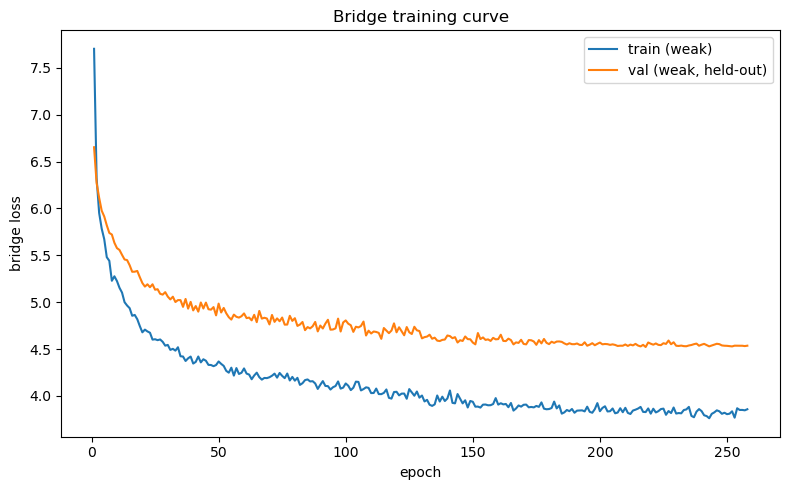

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train (weak)')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val (weak, held-out)')
plt.xlabel('epoch'); plt.ylabel('bridge loss'); plt.title('Bridge training curve'); plt.legend()
plt.tight_layout(); plt.show()

## 10. Bridge 평가

평가는 real milestone pair를 중심으로 봅니다.

- S2M MSE / cosine similarity
- M2S MSE / cosine similarity
- cycle MSE
- nearest neighbor consistency

In [30]:
@torch.no_grad()
def bridge_predict(idx):
    bridge_s2m.eval(); bridge_m2s.eval()
    zs = torch.tensor(Z_seq[idx], dtype=torch.float32, device=DEVICE)
    zm = torch.tensor(Z_smi[idx], dtype=torch.float32, device=DEVICE)
    cc = torch.tensor(C_raw[idx], dtype=torch.float32, device=DEVICE)
    return bridge_s2m(zs, cc).cpu().numpy(), bridge_m2s(zm, cc).cpu().numpy()

def cos_rows(a, b):
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
    return (a * b).sum(1)

def full_eval(tag, idx):
    nm = names_all[idx]
    s2m_pred, m2s_pred = bridge_predict(idx)
    r_s2m = retrieval_topk(s2m_pred, Z_smi[idx], nm, nm)
    r_m2s = retrieval_topk(m2s_pred, Z_seq[idx], nm, nm)
    fid = {'s2m_cos': round(float(cos_rows(s2m_pred, Z_smi[idx]).mean()), 3),
           'm2s_cos': round(float(cos_rows(m2s_pred, Z_seq[idx]).mean()), 3)}
    print(f'== {tag} (n={len(idx)}) ==')
    print(f'   S2M retrieval {r_s2m}   M2S retrieval {r_m2s}')
    print(f'   random        {random_topk(len(idx))}   latent cos {fid}')
    return s2m_pred, m2s_pred

print('MLP bridge (best-val checkpoint):')
full_eval('VAL  (weak held-out)', va_idx)
s2m_pred_te, m2s_pred_te = full_eval('TEST (real milestone)', te_idx)

# per-molecule NN 표 (real milestone) — 정직한 retrieval 점검용
def nn_table(pred, bank, names):
    sims = cosine_similarity(pred, bank); order = np.argsort(-sims, axis=1)
    rows = []
    for i in range(len(pred)):
        top3 = [names[j] for j in order[i, :min(3, len(names))]]
        rows.append({'query': names[i], 'top1': top3[0], 'top3': top3,
                     'top1_correct': names[i] == top3[0], 'top3_self': names[i] in top3})
    return pd.DataFrame(rows)
display(nn_table(s2m_pred_te, Z_smi[te_idx], names_all[te_idx]))

MLP bridge (best-val checkpoint):
== VAL  (weak held-out) (n=67) ==
   S2M retrieval {'top1': 0.254, 'top3': 0.567}   M2S retrieval {'top1': 0.418, 'top3': 0.687}
   random        {'top1': 0.015, 'top3': 0.045}   latent cos {'s2m_cos': 0.781, 'm2s_cos': 0.907}
== TEST (real milestone) (n=12) ==
   S2M retrieval {'top1': 0.583, 'top3': 0.75}   M2S retrieval {'top1': 0.417, 'top3': 0.833}
   random        {'top1': 0.083, 'top3': 0.25}   latent cos {'s2m_cos': 0.826, 'm2s_cos': 0.837}


,query,top1,top3,top1_correct,top3_self
0,GLP-1(7-36),GLP-1(7-36),"[GLP-1(7-36), Albiglutide, Taspoglutide]",True,True
1,GIP(1-42),GIP(1-42),"[GIP(1-42), Tirzepatide, Lixisenatide]",True,True
2,Glucagon(1-29),Glucagon(1-29),"[Glucagon(1-29), GIP(1-42), Lixisenatide]",True,True
3,Exenatide,Exenatide,"[Exenatide, Lixisenatide, Retatrutide]",True,True
4,Lixisenatide,Exenatide,"[Exenatide, Lixisenatide, Retatrutide]",False,True
5,Liraglutide,Taspoglutide,"[Taspoglutide, Liraglutide, Albiglutide]",False,True
6,Albiglutide,Albiglutide,"[Albiglutide, GLP-1(7-36), Taspoglutide]",True,True
7,Taspoglutide,Taspoglutide,"[Taspoglutide, Albiglutide, GLP-1(7-36)]",True,True
8,Dulaglutide,Albiglutide,"[Albiglutide, Taspoglutide, GLP-1(7-36)]",False,False
9,Semaglutide,Taspoglutide,"[Taspoglutide, Albiglutide, GLP-1(7-36)]",False,False


## 10.5 디코더 기반 검증 (latent-only 지표의 한계 보완)

latent MSE/cosine은 필요조건일 뿐입니다. **bridge된 latent가 디코딩 시 말이 되는지**를 봐야 합니다.

- **중요**: bridge는 *StandardScale된* 공간에서 동작하므로, 디코더에 넣기 전 반드시
  `scaler.inverse_transform`으로 **raw VAE latent로 되돌려야** 합니다. (이걸 빼면 조용히 망가집니다.)
- Sequence 디코더(M2S round-trip)와 SMILES 디코더(S2M round-trip)를 **둘 다** 검증합니다.
- SMILES 디코더는 `SMILES_VAE_final.ipynb`의 `GRUSELFIESDecoder`와 **동일 구조로 재구성**해
  `smi_decoder.*` 가중치를 strict 로드합니다 (10.6 참조).


In [31]:
# ---- Sequence 디코더 round-trip (M2S: z_smi -> z_seq_pred -> sequence) ----
inv_stoi = {v: k for k, v in seq_stoi.items()}

def ids_to_seq(ids):
    out = []
    for i in ids:
        ch = inv_stoi.get(int(i), '')
        if ch == SEQ_SOS:  continue
        if ch == SEQ_EOS:  break
        if ch == SEQ_PAD:  continue
        out.append(ch)
    return ''.join(out)

@torch.no_grad()
def decode_seq_from_scaled_z(z_seq_scaled_row, cond_row):
    z_raw = seq_scaler.inverse_transform(z_seq_scaled_row.reshape(1, -1)).astype('float32')  # *** un-scale ***
    z = torch.tensor(z_raw, device=DEVICE)
    c = torch.tensor(cond_row.reshape(1, -1), dtype=torch.float32, device=DEVICE)
    logits = sequence_model.decode(z, c)          # (1, max_len, vocab)
    ids = logits.argmax(-1).squeeze(0).cpu().numpy()
    return ids_to_seq(ids)

def token_acc(a, b):
    n = min(len(a), len(b))
    return (sum(x == y for x, y in zip(a, b)) / n) if n else 0.0

print('=== M2S decode round-trip on TEST (real milestone) ===')
seqs_true = latent_df.loc[te_idx, 'sequence'].astype(str).values
rows = []
for n, zrow, crow, st in zip(names_all[te_idx], m2s_pred_te, C_raw[te_idx], seqs_true):
    dec = decode_seq_from_scaled_z(zrow, crow)
    rows.append({'name': n, 'decoded': dec[:40], 'true': st[:40],
                 'tok_acc': round(token_acc(dec, st), 3), 'exact': dec == st})
display(pd.DataFrame(rows))


=== M2S decode round-trip on TEST (real milestone) ===


,name,decoded,true,tok_acc,exact
0,GLP-1(7-36),HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,1.000,True
1,GIP(1-42),YAEGTFISDYSIAMDKIRQQDFVNWLLAQKGKKNDWKHNI,YAEGTFISDYSIAMDKIHQQDFVNWLLAQKGKKNDWKHNI,0.976,False
2,Glucagon(1-29),HSQGTFTSDYSKYLDSRRAQDFVQWLMNT,HSQGTFTSDYSKYLDSRRAQDFVQWLMNT,1.000,True
3,Exenatide,HSEGTFTSDLSSYLEEQAAKEFVAWLVKGG,HGEGTFTSDLSKQMEEEAVRLFIEWLKNGGPSSGAPPPS,0.600,False
4,Lixisenatide,HSEGTFTSDLSSYLEEQAAKEFVAWLVKGG,HGEGTFTSDLSKQMEEEAVRLFIEWLKNGGPSSGAPPSKK,0.600,False
5,Liraglutide,HAEGTFTSDVSSYLEGQAAKEFVAWLVKGR,HAEGTFTSDVSSYLEGQAAKEEFIAWLVRGRG,0.700,False
6,Albiglutide,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,HGEGTFTSDVSSYLEGQAAKEFIAWLVKGR,0.967,False
7,Taspoglutide,HAEGTFTSDVSSYLEDQAAKEFVAWLKKGR,HXEGTFTSDVSSYLEGQAAKEFIAWLVKXR,0.833,False
8,Dulaglutide,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,HGEGTFTSDVSSYLEEQAAKEFIAWLVKGGG,0.900,False
9,Semaglutide,HAEGTFTSDMSKYLDEQAAKEFVAWLINGK,HXEGTFTSDVSSYLEGQAAKEFIAWLVRGRG,0.700,False


## 10.6 SMILES 디코더 round-trip (S2M)

`SMILES_VAE_final.ipynb`의 `GRUSELFIESDecoder`와 **동일 구조**로 `smi_decoder`를 재구성하고
체크포인트의 `smi_decoder.*` 가중치를 strict 로드합니다. 구조 요약:

- 매 스텝 `[token_emb, z, cond]` concat (원본 Option C), h0 = `tanh(fc_init([z, cond]))`
- 차원은 metadata에서: `latent_dim`, `emb_dim`, `dec_gru_dim`, `dec_n_layers`

검증은 두 가지를 분리해서 봅니다.

- **(a) VAE 자체 reconstruction**: 원본 raw `z_smi` -> greedy -> SMILES. 디코더/로드가 정상인지의 sanity check (bridge 무관).
- **(b) Bridge S2M**: `bridge_s2m(z_seq)`(scaled) -> `inverse_transform` -> raw `z_smi` -> greedy -> SMILES.
  true milestone SMILES와 Tanimoto(Morgan, radius=RADIUS) 비교.

(a)가 낮으면 SMILES VAE 디코더 자체 한계, (a)는 높은데 (b)만 낮으면 **Bridge 매핑 문제**로 진단이 분리됩니다.


In [32]:
# ===== SMILES 디코더(GRUSELFIESDecoder) 복원 + strict 로드 =====
# SMILES_VAE_final.ipynb 정의와 동일 구조 -> smi_decoder.* 키가 그대로 매칭됨.
DEC_GRU_DIM  = int(smi_meta['model'].get('dec_gru_dim', 128))
DEC_N_LAYERS = int(smi_meta['model'].get('dec_n_layers', 1))
print('decoder dims: gru_dim=%d n_layers=%d emb=%d latent=%d n_cond=%d'
      % (DEC_GRU_DIM, DEC_N_LAYERS, EMB_DIM, LATENT_DIM, N_COND))

class GRUSELFIESDecoder(nn.Module):
    """매 스텝 emb + z + cond concat (원본 Option C와 동일 구조)"""
    def __init__(self):
        super().__init__()
        gru_in = EMB_DIM + LATENT_DIM + N_COND
        self.fc_init   = nn.Linear(LATENT_DIM + N_COND, DEC_GRU_DIM * DEC_N_LAYERS)
        self.token_emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=PAD_IDX)
        self.gru       = nn.GRU(gru_in, DEC_GRU_DIM, num_layers=DEC_N_LAYERS, batch_first=True)
        self.dropout   = nn.Dropout(DROPOUT)
        self.fc_out    = nn.Linear(DEC_GRU_DIM, VOCAB_SIZE)

    def _init_hidden(self, z, cond):
        h = torch.tanh(self.fc_init(torch.cat([z, cond], dim=-1)))
        B = z.size(0)
        return h.view(B, DEC_N_LAYERS, DEC_GRU_DIM).permute(1, 0, 2).contiguous()

    @torch.no_grad()
    def greedy(self, z, cond, max_len=None):
        if max_len is None:
            max_len = MAX_LEN
        B = z.size(0)
        h = self._init_hidden(z, cond)
        token = torch.full((B, 1), SOS_IDX, dtype=torch.long, device=z.device)
        gen_ids = [[] for _ in range(B)]
        finished = torch.zeros(B, dtype=torch.bool, device=z.device)
        for _ in range(max_len):
            emb = self.token_emb(token)
            inp = torch.cat([emb, z.unsqueeze(1), cond.unsqueeze(1)], dim=-1)
            out, h = self.gru(inp, h)
            logit = self.fc_out(out.squeeze(1))
            logit[:, UNK_IDX] = -1e9          # 원본과 동일하게 UNK 금지
            nxt = logit.argmax(dim=-1)
            for b in range(B):
                if not finished[b]:
                    t = int(nxt[b].item()); gen_ids[b].append(t)
                    if t == EOS_IDX:
                        finished[b] = True
            if finished.all():
                break
            nxt = torch.where(finished, torch.full_like(nxt, PAD_IDX), nxt)
            token = nxt.unsqueeze(1)
        return gen_ids[0] if B == 1 else gen_ids

smi_decoder = GRUSELFIESDecoder().to(DEVICE)
dec_state = {k[len('smi_decoder.'):]: v for k, v in smi_state.items() if k.startswith('smi_decoder.')}
missing, unexpected = smi_decoder.load_state_dict(dec_state, strict=False)
smi_decoder.eval()

print('smi_decoder loaded | params=%d' % len(dec_state))
print('  missing   :', missing)
print('  unexpected:', unexpected)
assert len(dec_state) > 0, 'smi_decoder.* 키가 체크포인트에 없습니다 (encoder-only 저장?).'
assert len(missing) == 0, '디코더 가중치 일부 미로드 — 구조 불일치를 확인하세요.'
SMILES_DECODE_AVAILABLE = True
print('SMILES_DECODE_AVAILABLE =', SMILES_DECODE_AVAILABLE)


decoder dims: gru_dim=128 n_layers=1 emb=64 latent=128 n_cond=3
smi_decoder loaded | params=9
  missing   : []
  unexpected: []
SMILES_DECODE_AVAILABLE = True


In [33]:
# ===== SMILES round-trip 검증: (a) VAE recon  (b) Bridge S2M =====
from rdkit.Chem import AllChem, DataStructs

def ids_to_smiles_dec(ids):
    """token ids -> de-BPE(이어붙임) -> SELFIES -> SMILES (canonical). 원본 ids_to_smiles와 동일 규약."""
    toks = []
    for i in ids:
        i = int(i)
        if i == EOS_IDX:
            break
        if i in (PAD_IDX, SOS_IDX, UNK_IDX):
            continue
        toks.append(bpe_i2c.get(i, ''))
    sf_str = ''.join(toks)
    try:
        smi = sf.decoder(sf_str)
    except Exception:
        return None
    return canonicalize_smiles(smi) if smi else None

def tanimoto(s1, s2):
    if not s1 or not s2:
        return None
    m1, m2 = Chem.MolFromSmiles(str(s1)), Chem.MolFromSmiles(str(s2))
    if m1 is None or m2 is None:
        return None
    f1 = AllChem.GetMorganFingerprintAsBitVect(m1, RADIUS, N_BITS_MG)
    f2 = AllChem.GetMorganFingerprintAsBitVect(m2, RADIUS, N_BITS_MG)
    return DataStructs.TanimotoSimilarity(f1, f2)

if SMILES_DECODE_AVAILABLE and len(te_idx) > 0:
    # cond는 디코더 학습 순서(COND_LABELS) multi-hot으로 — Bridge [GLP1R,GIPR,GCGR]에서 자동 변환
    cond_te = torch.tensor(
        [condition_for_smiles_model(int(a), int(b), int(c)) for a, b, c in C_raw[te_idx]],
        dtype=torch.float32, device=DEVICE)

    # (a) VAE 자체 recon: 원본 raw z_smi (= 인코더 mu) -> greedy
    z_recon = torch.tensor(Z_smi_raw[te_idx], dtype=torch.float32, device=DEVICE)
    ids_recon = [
        smi_decoder.greedy(z_recon[k:k+1], cond_te[k:k+1])
        for k in range(len(te_idx))
    ]

    # (b) Bridge S2M: s2m_pred_te(scaled) -> inverse_transform -> raw z_smi -> greedy
    z_bridge = torch.tensor(smi_scaler.inverse_transform(s2m_pred_te).astype('float32'),
                            dtype=torch.float32, device=DEVICE)
    ids_bridge = [
        smi_decoder.greedy(z_bridge[k:k+1], cond_te[k:k+1])
        for k in range(len(te_idx))
    ]

    if len(te_idx) == 1:        # greedy는 B==1일 때 단일 리스트를 반환
        ids_recon, ids_bridge = [ids_recon], [ids_bridge]

    smi_true = latent_df['smiles'].astype(str).values[te_idx]
    rows = []
    for k in range(len(te_idx)):
        rec = ids_to_smiles_dec(ids_recon[k])
        brd = ids_to_smiles_dec(ids_bridge[k])
        t_rec = tanimoto(rec, smi_true[k])
        t_brd = tanimoto(brd, smi_true[k])
        rows.append({
            'name'            : names_all[te_idx][k],
            'recon_valid'     : rec is not None,
            'recon_tani(VAE)' : (round(t_rec, 3) if t_rec is not None else None),
            'bridge_valid'    : brd is not None,
            'bridge_tani(S2M)': (round(t_brd, 3) if t_brd is not None else None),
            'bridge_smiles'   : (brd or '')[:48],
        })
    df_smi_decode = pd.DataFrame(rows)
    display(df_smi_decode)

    vr = df_smi_decode['recon_valid'].mean()
    vb = df_smi_decode['bridge_valid'].mean()
    mr = df_smi_decode['recon_tani(VAE)'].dropna().mean()
    mb = df_smi_decode['bridge_tani(S2M)'].dropna().mean()
    print(f'validity   recon(VAE)={vr:.2f}   bridge(S2M)={vb:.2f}')
    print(f'mean tani  recon(VAE)={mr:.3f}   bridge(S2M)={mb:.3f}')
    print('해석: recon이 낮으면 SMILES VAE 디코더 자체 한계, '
          'recon은 높은데 bridge만 낮으면 Bridge 매핑 문제로 분리 진단.')
else:
    print('SMILES_DECODE_AVAILABLE=False 또는 test 비어 있음 — 디코드 검증 생략')


,name,recon_valid,recon_tani(VAE),bridge_valid,bridge_tani(S2M),bridge_smiles
0,GLP-1(7-36),True,0.662,True,0.599,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CCC(=O)O)NC(=O
1,GIP(1-42),True,1.000,True,1.000,CCC(C)C(NC(=O)C(CO)NC(=O)C(Cc1ccc(O)cc1)NC(=O)C(
2,Glucagon(1-29),True,1.000,True,1.000,CSCCC(NC(=O)C(CC(C)C)NC(=O)C(Cc1c[nH]c2ccccc12)N
3,Exenatide,True,1.000,True,1.000,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CC(C)C)NC(=O)C
4,Lixisenatide,True,0.948,True,0.948,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CC(C)C)NC(=O)C
5,Liraglutide,True,0.815,True,0.815,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CCC(=O)O)NC(=O
6,Albiglutide,True,0.942,True,0.793,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CCC(=O)O)NC(=O
7,Taspoglutide,True,0.916,True,0.916,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CCC(=O)O)NC(=O
8,Dulaglutide,True,0.845,True,0.719,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CCC(=O)O)NC(=O
9,Semaglutide,True,1.000,True,0.855,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CCC(=O)O)NC(=O


validity   recon(VAE)=1.00   bridge(S2M)=1.00
mean tani  recon(VAE)=0.927   bridge(S2M)=0.840
해석: recon이 낮으면 SMILES VAE 디코더 자체 한계, recon은 높은데 bridge만 낮으면 Bridge 매핑 문제로 분리 진단.


## 11. PCA 시각화

real milestone 기준으로 실제 `z_smi`와 `Bridge_S2M(z_seq)`를 같은 PCA 공간에 표시합니다.

점선이 짧을수록 sequence latent에서 SMILES latent로 잘 이동한 것입니다.

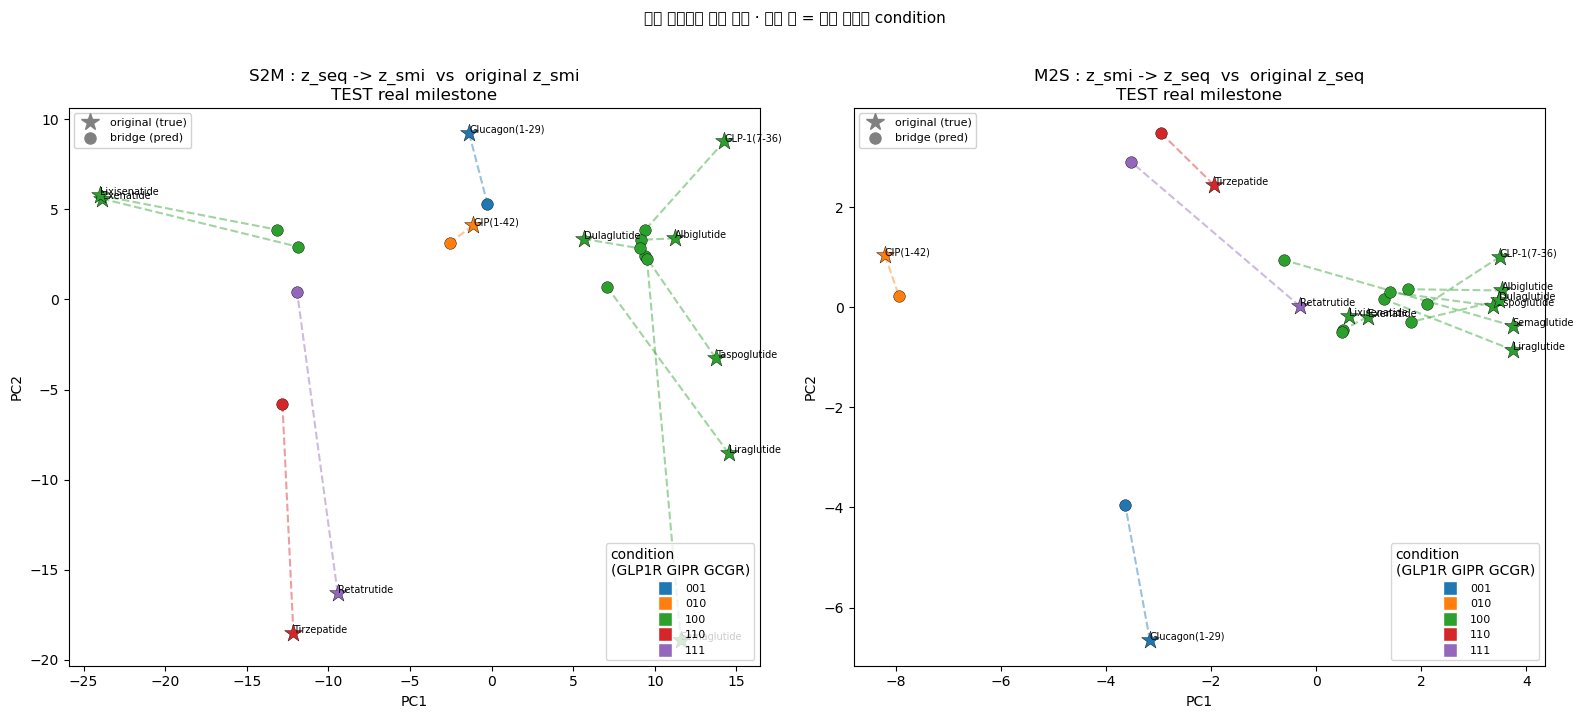

In [34]:
from matplotlib.lines import Line2D

def _scatter_pair(ax, true_mat, pred_mat, names, cond_str, title):
    'true(원본 latent)와 pred(bridge 변환 latent)를 같은 PCA 공간에 투영해 짝끼리 잇는다.'
    combined = np.vstack([true_mat, pred_mat])
    xy = PCA(n_components=2, random_state=SEED).fit_transform(combined)
    n = len(true_mat); true_xy, pred_xy = xy[:n], xy[n:]

    uniq = sorted(set(cond_str))
    cmap = plt.get_cmap('tab10')
    cdict = {c: cmap(k % 10) for k, c in enumerate(uniq)}

    for i in range(n):
        col = cdict[cond_str[i]]
        ax.scatter(*true_xy[i], marker='*', s=180, color=col, edgecolor='k', linewidth=0.3, zorder=3)
        ax.scatter(*pred_xy[i], marker='o', s=70,  color=col, edgecolor='k', linewidth=0.3, zorder=3)
        ax.plot([true_xy[i, 0], pred_xy[i, 0]], [true_xy[i, 1], pred_xy[i, 1]],
                '--', color=col, alpha=0.45, zorder=1)
        if n <= 20:
            ax.text(true_xy[i, 0], true_xy[i, 1], str(names[i]), fontsize=7)

    marker_handles = [
        Line2D([0], [0], marker='*', color='gray', linestyle='None', markersize=13, label='original (true)'),
        Line2D([0], [0], marker='o', color='gray', linestyle='None', markersize=8,  label='bridge (pred)'),
    ]
    cond_handles = [Line2D([0], [0], marker='s', color='w', markerfacecolor=cdict[c],
                           markersize=10, label=c) for c in uniq]
    leg1 = ax.legend(handles=marker_handles, loc='upper left', fontsize=8, framealpha=0.9)
    ax.add_artist(leg1)
    ax.legend(handles=cond_handles, title='condition\n(GLP1R GIPR GCGR)', loc='lower right', fontsize=8)
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

def plot_bridge_pca(tag, idx):
    'S2M(z_seq->z_smi)과 M2S(z_smi->z_seq)를 각각 원본 latent과 함께 나란히 시각화.'
    s2m_pred, m2s_pred = bridge_predict(idx)
    nm = names_all[idx]
    cond_str = latent_df['condition'].astype(str).values[idx]   # 위치 기반(positional) 추출

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    _scatter_pair(axes[0], Z_smi[idx], s2m_pred, nm, cond_str,
                  f'S2M : z_seq -> z_smi  vs  original z_smi\n{tag}')
    _scatter_pair(axes[1], Z_seq[idx], m2s_pred, nm, cond_str,
                  f'M2S : z_smi -> z_seq  vs  original z_seq\n{tag}')
    fig.suptitle('점선 짧을수록 정렬 양호 · 같은 색 = 같은 수용체 condition', y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()

# real milestone(held-out test)
plot_bridge_pca('TEST real milestone', te_idx)

# 참고: weak held-out(val)도 같은 방식으로 볼 수 있음 (점이 많아 이름표는 자동 생략)
# plot_bridge_pca('VAL weak held-out', va_idx)


12. 저장

In [35]:
BRIDGE_S2M_PATH = os.path.join(OUT_DIR, 'bridge_s2m.pt')
BRIDGE_M2S_PATH = os.path.join(OUT_DIR, 'bridge_m2s.pt')
HISTORY_PATH    = os.path.join(OUT_DIR, 'bridge_training_history.csv')
SCALER_PATH     = os.path.join(OUT_DIR, 'bridge_scalers.pkl')
CONFIG_PATH     = os.path.join(OUT_DIR, 'bridge_config.json')

torch.save(bridge_s2m.state_dict(), BRIDGE_S2M_PATH)
torch.save(bridge_m2s.state_dict(), BRIDGE_M2S_PATH)
history_df.to_csv(HISTORY_PATH, index=False)
with open(SCALER_PATH, 'wb') as f:
    pickle.dump({'seq_scaler': seq_scaler, 'smi_scaler': smi_scaler}, f)
with open(CONFIG_PATH, 'w') as f:
    json.dump({'seq_latent_dim': int(SEQ_LATENT_DIM), 'smi_latent_dim': int(SMI_LATENT_DIM),
               'use_cond_input': bool(USE_COND_INPUT), 'hidden': int(BRIDGE_HIDDEN),
               'dropout': float(BRIDGE_DROPOUT), 'loss_kw': LOSS_KW,
               'split': {'train': int(len(tr_idx)), 'val': int(len(va_idx)), 'test': int(len(te_idx))}},
              f, indent=2)
print('Saved:', BRIDGE_S2M_PATH, BRIDGE_M2S_PATH, HISTORY_PATH, SCALER_PATH, CONFIG_PATH, sep='\n')

Saved:
MLProject/bridge/bridge_s2m.pt
MLProject/bridge/bridge_m2s.pt
MLProject/bridge/bridge_training_history.csv
MLProject/bridge/bridge_scalers.pkl
MLProject/bridge/bridge_config.json
